In [3]:
import piplite
# We install all three, skipping dependencies to avoid the pandas/matplotlib version conflict
await piplite.install(['seaborn', 'mlxtend', 'missingno'], deps=False)
print("Installation successful!")


Installation successful!


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
from mlxtend.plotting import plot_decision_regions
import missingno as msno
from pandas.plotting import scatter_matrix
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [8]:
import os
os.listdir()

['Corelation between diabities and number of Pregnancies . Mohammad Zubair Sheikh.ipynb',
 'Corelation between diabities and number of Pregnancies . Mohammad Zubair Sheikh1.ipynb',
 'DAY 19.ipynb',
 'Untitled10.ipynb',
 'Untitled6.ipynb',
 'Untitled7.ipynb',
 'Untitled8.ipynb',
 'Updated Co-relation between diabetes and number of pregnancies in Pakistani women 1 2 - Copy(in).csv',
 'README.md',
 'data',
 'notebooks']

In [9]:
#Importing data in Jupyte

pak_df = pd.read_csv("Updated Co-relation between diabetes and number of pregnancies in Pakistani women 1 2 - Copy(in).csv")

In [7]:
#To check data first 5 rows
pak_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Unnamed: 9
0,6.0,148.0,72.0,35.0,169.0,33.6,0.627,50.0,1,NaN
1,1.0,85.0,66.0,29.0,169.0,26.6,0.351,31.0,0,NaN
2,8.0,183.0,64.0,33.0,169.0,23.3,0.672,32.0,1,NaN
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0,NaN
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,1,NaN


In [22]:
#Total number of columns in the dataset
pak_df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [23]:
#Information about dataset
pak_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [24]:
# To know more about the dataset
pak_df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [26]:
# To know more about the dataset with transpose
pak_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [27]:
# To check if there is some null values or not
pak_df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [37]:
# Showing the count of NaNs
pak_df_copy = pak_df.copy()

total_nan = pak_df_copy.isnull().sum().sum()
print("Total NaN values:", total_nan)

nan_count = pak_df_copy.isnull().sum()
print(nan_count[nan_count > 0])

Total NaN values: 0
Series([], dtype: int64)


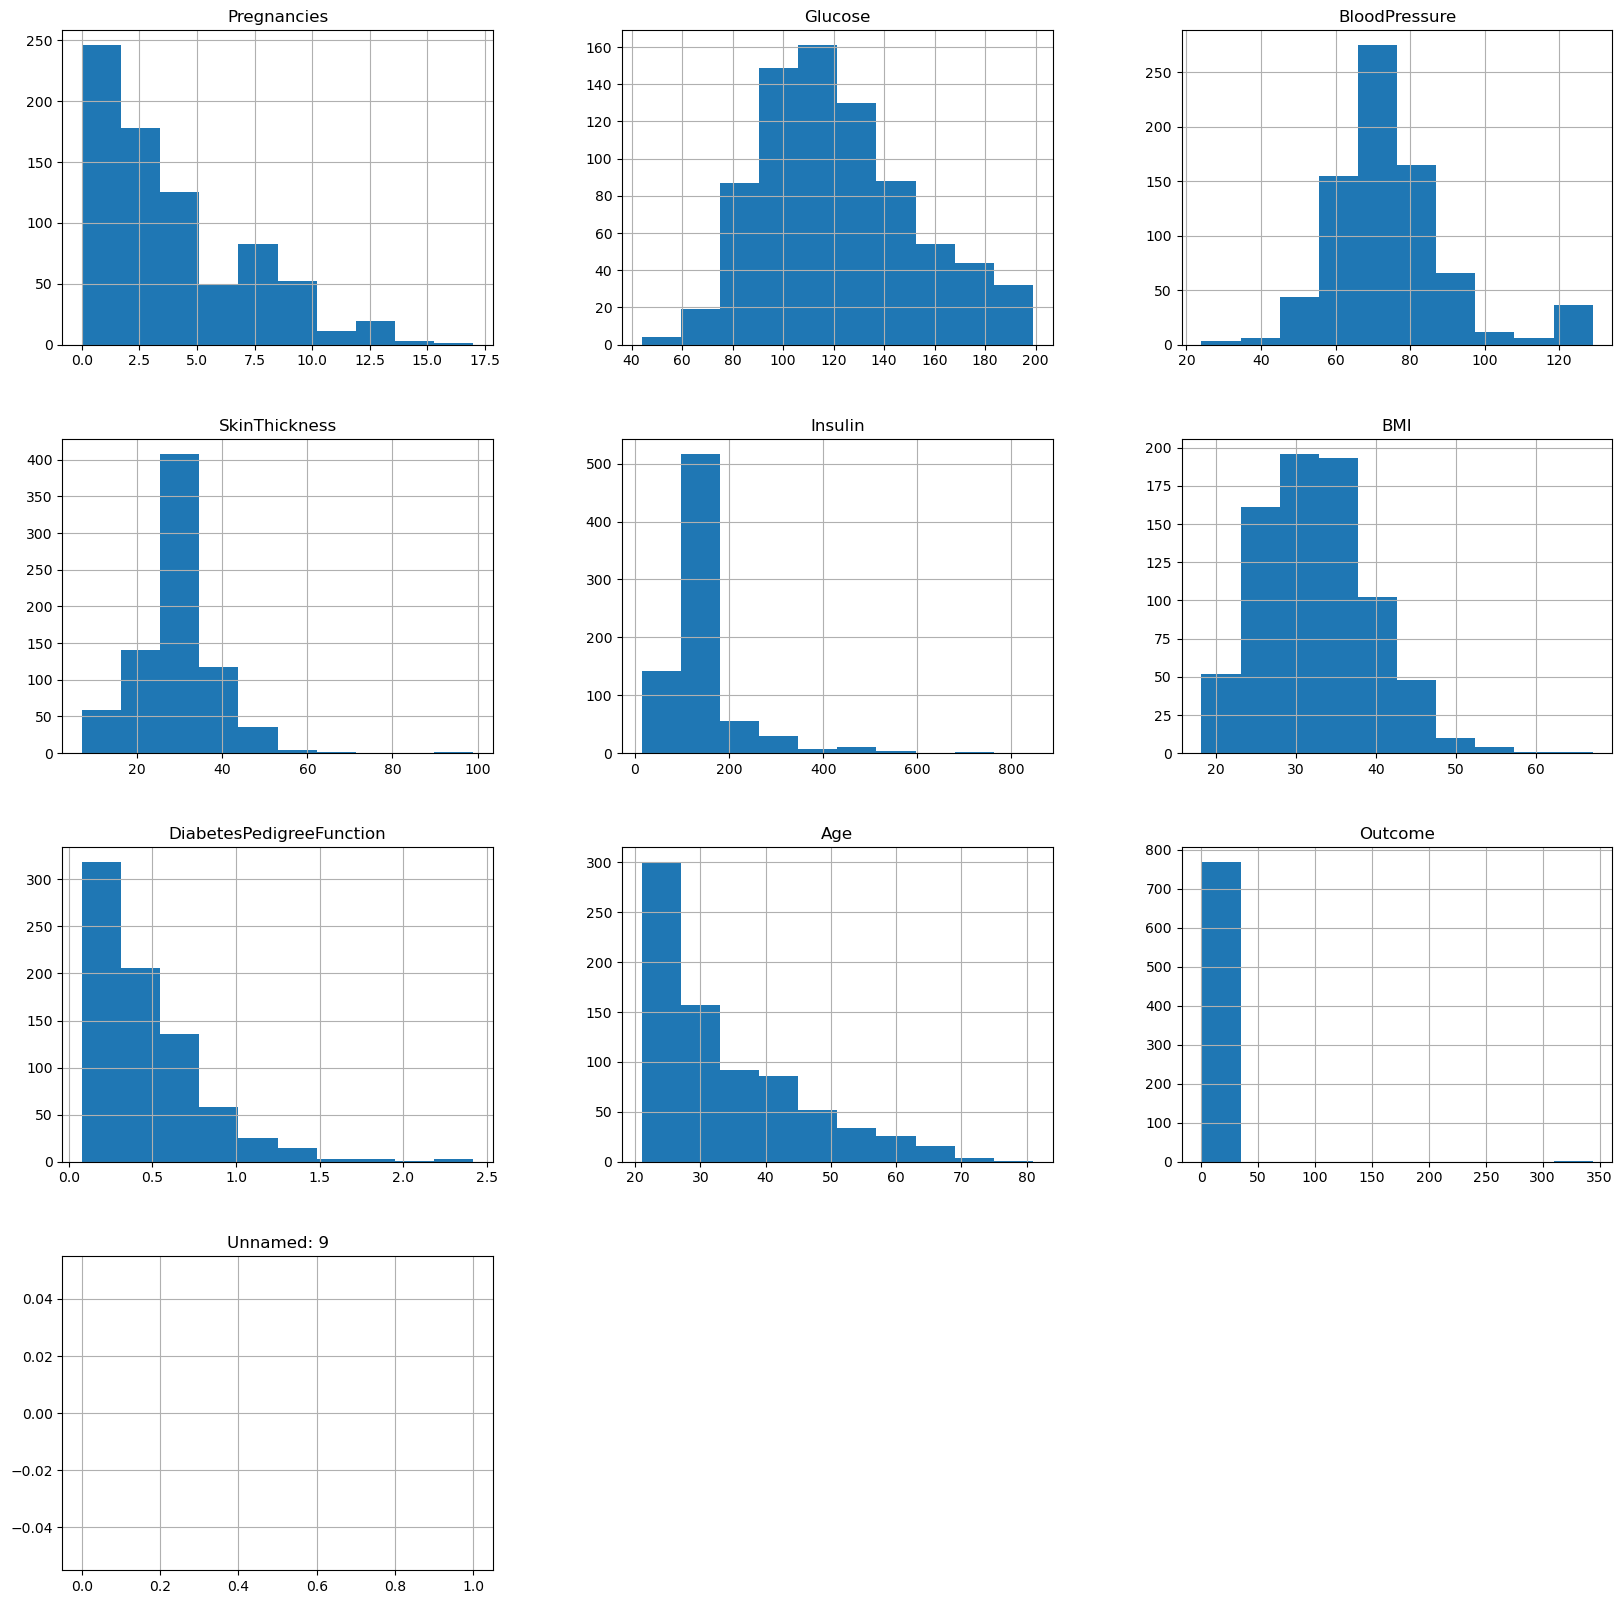

In [13]:

import matplotlib.pyplot as plt

p = pak_df.hist(figsize=(20, 20))
plt.show()

In [ ]:
print(pak_df)


<Axes: xlabel='Pregnancies', ylabel='Glucose'>

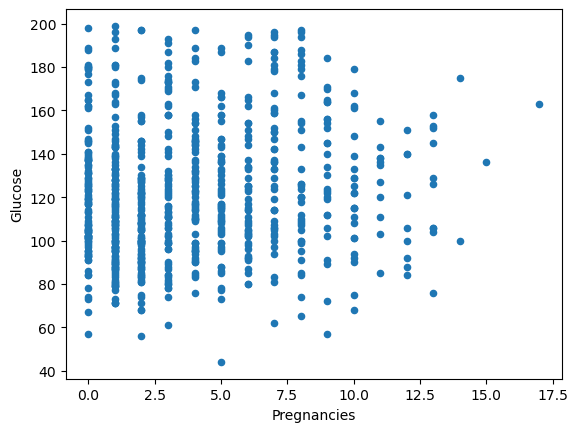

In [14]:
pak_df.plot.scatter("Pregnancies","Glucose")

In [51]:
pak_df.loc[0, "Glucose"] = 120

In [52]:
pak_df.loc[0, "Bloodpressure"] = 90

In [53]:
pak_df.loc[0, "SkinThickness"] = 32

<Axes: title={'center': 'Pregnancies'}, xlabel='Outcome'>

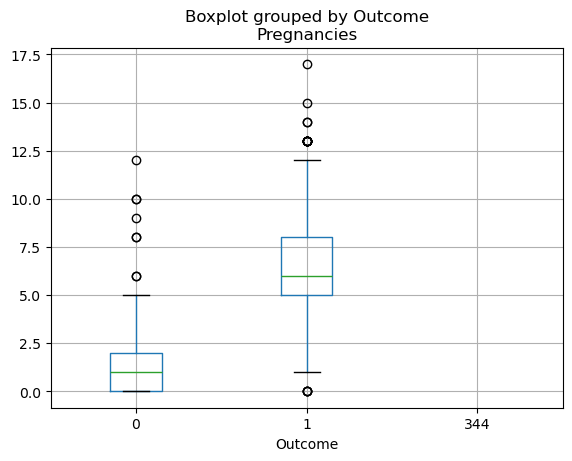

In [15]:
pak_df.boxplot("Pregnancies","Outcome")

In [4]:
import pandas as pd
from scipy.stats import ttest_ind

pak_df = pd.read_csv("Updated Co-relation between diabetes and number of pregnancies in Pakistani women 1 2 - Copy(in).csv")

# Check column names
print(pak_df.columns)

# Separate the two groups
diabetic = pak_df[pak_df["Outcome"] == 1]["Pregnancies"]
non_diabetic = pak_df[pak_df["Outcome"] == 0]["Pregnancies"]

# Independent t-test
t_stat, p_value = ttest_ind(diabetic, non_diabetic, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome', 'Unnamed: 9'],
      dtype='object')
T-statistic: 31.078205168976528
P-value: 5.625458761020929e-119


In [3]:
# Chi-Square Test


import pandas as pd
from scipy.stats import chi2_contingency

# Load dataset
pak_df = pd.read_csv("Updated Co-relation between diabetes and number of pregnancies in Pakistani women 1 2 - Copy(in).csv")

# Check column names
print(pak_df.columns)

# Create pregnancy groups
pak_df["Pregnancy_Group"] = pd.cut(
    pak_df["Pregnancies"],
    bins=[-1, 0, 3, 6, 20],
    labels=["0 pregnancies", "1-3 pregnancies", "4-6 pregnancies", "7+ pregnancies"]
)

# Create contingency table
contingency_table = pd.crosstab(pak_df["Pregnancy_Group"], pak_df["Outcome"])


#print(contingency_table)

# Chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-square value:", chi2)
print("P-value:", p_value)
print("Degrees of freedom:", dof)
print("Expected frequencies:")
print(expected)

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome', 'Unnamed: 9'],
      dtype='object')
Outcome            0    1
Pregnancy_Group          
0 pregnancies    107    4
1-3 pregnancies  302   11
4-6 pregnancies    9  166
7+ pregnancies     6  163
Chi-square value: 651.562979501061
P-value: 6.675441153323282e-141
Degrees of freedom: 3
Expected frequencies:
[[ 61.28125     49.71875   ]
 [172.80208333 140.19791667]
 [ 96.61458333  78.38541667]
 [ 93.30208333  75.69791667]]


In [5]:
#Create contingency table
contingency_table = pd.crosstab(pak_df["Pregnancy_Group"], pak_df["Age"])
print("Chi-square value:", chi2)
print("P-value:", p_value)
print("Degrees of freedom:", dof)
print("Expected frequencies:")
print(expected)


Chi-square value: 651.562979501061
P-value: 6.675441153323282e-141
Degrees of freedom: 3
Expected frequencies:
[[ 61.28125     49.71875   ]
 [172.80208333 140.19791667]
 [ 96.61458333  78.38541667]
 [ 93.30208333  75.69791667]]


In [6]:
# Create contingency table
contingency_table = pd.crosstab(pak_df["Pregnancy_Group"], pak_df["Glucose"])
print("Chi-square value:", chi2)
print("P-value:", p_value)
print("Degrees of freedom:", dof)
print("Expected frequencies:")
print(expected)

Chi-square value: 651.562979501061
P-value: 6.675441153323282e-141
Degrees of freedom: 3
Expected frequencies:
[[ 61.28125     49.71875   ]
 [172.80208333 140.19791667]
 [ 96.61458333  78.38541667]
 [ 93.30208333  75.69791667]]


In [7]:
# Create contingency table
contingency_table = pd.crosstab(pak_df["Pregnancy_Group"], pak_df["BloodPressure"])
print("Chi-square value:", chi2)
print("P-value:", p_value)
print("Degrees of freedom:", dof)
print("Expected frequencies:")
print(expected)

Chi-square value: 651.562979501061
P-value: 6.675441153323282e-141
Degrees of freedom: 3
Expected frequencies:
[[ 61.28125     49.71875   ]
 [172.80208333 140.19791667]
 [ 96.61458333  78.38541667]
 [ 93.30208333  75.69791667]]


In [14]:
# Create contingency table
contingency_table = pd.crosstab(pak_df["Pregnancy_Group"], pak_df["SkinThickness"])
print("Chi-square value:", chi2)
print("P-value:", p_value)
print("Degrees of freedom:", dof)
print("Expected frequencies:")
print(expected)

Chi-square value: 651.562979501061
P-value: 6.675441153323282e-141
Degrees of freedom: 3
Expected frequencies:
[[ 61.28125     49.71875   ]
 [172.80208333 140.19791667]
 [ 96.61458333  78.38541667]
 [ 93.30208333  75.69791667]]


In [15]:
# Create contingency table
contingency_table = pd.crosstab(pak_df["Pregnancy_Group"], pak_df["Insulin"])
print("Chi-square value:", chi2)
print("P-value:", p_value)
print("Degrees of freedom:", dof)
print("Expected frequencies:")
print(expected)

Chi-square value: 651.562979501061
P-value: 6.675441153323282e-141
Degrees of freedom: 3
Expected frequencies:
[[ 61.28125     49.71875   ]
 [172.80208333 140.19791667]
 [ 96.61458333  78.38541667]
 [ 93.30208333  75.69791667]]


In [16]:
# Create contingency table
contingency_table = pd.crosstab(pak_df["Pregnancy_Group"], pak_df["BMI"])
print("Chi-square value:", chi2)
print("P-value:", p_value)
print("Degrees of freedom:", dof)
print("Expected frequencies:")
print(expected)

Chi-square value: 651.562979501061
P-value: 6.675441153323282e-141
Degrees of freedom: 3
Expected frequencies:
[[ 61.28125     49.71875   ]
 [172.80208333 140.19791667]
 [ 96.61458333  78.38541667]
 [ 93.30208333  75.69791667]]


In [19]:
# Create contingency table
contingency_table = pd.crosstab(pak_df["Pregnancy_Group"], pak_df["Insulin"])
print("Chi-square value:", chi2)
print("P-value:", p_value)
print("Degrees of freedom:", dof)
print("Expected frequencies:")
print(expected)

Chi-square value: 651.562979501061
P-value: 6.675441153323282e-141
Degrees of freedom: 3
Expected frequencies:
[[ 61.28125     49.71875   ]
 [172.80208333 140.19791667]
 [ 96.61458333  78.38541667]
 [ 93.30208333  75.69791667]]


In [23]:
pak_df["DPF_Group"] = pd.cut(
    pak_df["DiabetesPedigreeFunction"],
    bins=[0, 0.3, 0.6, 1.0, 3],
    labels=["Low", "Medium", "High", "Very High"]
)

contingency_table = pd.crosstab(
    pak_df["Pregnancy_Group"],
    pak_df["DPF_Group"]
)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-square value:", chi2)
print("P-value:", p_value)
print("Degrees of freedom:", dof)
print("Expected frequencies:")

Chi-square value: 7.579949625363661
P-value: 0.5769666266212942
Degrees of freedom: 9
Expected frequencies:


In [28]:
import pandas as pd
from scipy.stats import chi2_contingency

# Create glucose groups
pak_df["Glucose_Group"] = pd.cut(
    pak_df["Glucose"],
    bins=[50,70, 90, 100, 140, 300],
    labels=["Very Low", "Low", "Medium", "High", "Very High"]
)

# Create contingency table
contingency_table = pd.crosstab(
    pak_df["Pregnancy_Group"],
    pak_df["Glucose_Group"]
)

print(contingency_table)

# Chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-square value:", chi2)
print("P-value:", p_value)
print("Degrees of freedom:", dof)
print("Expected frequencies:")
print(expected)

Glucose_Group    Very Low  Low  Medium  High  Very High
Pregnancy_Group                                        
0 pregnancies           2    6      15    63         25
1-3 pregnancies         4   63      47   139         60
4-6 pregnancies         0   17      23    87         47
7+ pregnancies          4   13      14    78         60
Chi-square value: 45.37376306569955
P-value: 8.890948938250655e-06
Degrees of freedom: 12
Expected frequencies:
[[  1.44719687  14.32724902  14.32724902  53.11212516  27.78617992]
 [  4.08083442  40.40026076  40.40026076 149.76662321  78.35202086]
 [  2.26857888  22.4589309   22.4589309   83.25684485  43.55671447]
 [  2.20338983  21.81355932  21.81355932  80.86440678  42.30508475]]
